(14606, 26)
(193002, 8)
id                                    str
channel_sales                         str
cons_12m                            int64
cons_gas_12m                        int64
cons_last_month                     int64
date_activ                            str
date_end                              str
date_modif_prod                       str
date_renewal                          str
forecast_cons_12m                 float64
forecast_cons_year                  int64
forecast_discount_energy          float64
forecast_meter_rent_12m           float64
forecast_price_energy_off_peak    float64
forecast_price_energy_peak        float64
forecast_price_pow_off_peak       float64
has_gas                               str
imp_cons                          float64
margin_gross_pow_ele              float64
margin_net_pow_ele                float64
nb_prod_act                         int64
net_margin                        float64
num_years_antig                     int64
origin_up 

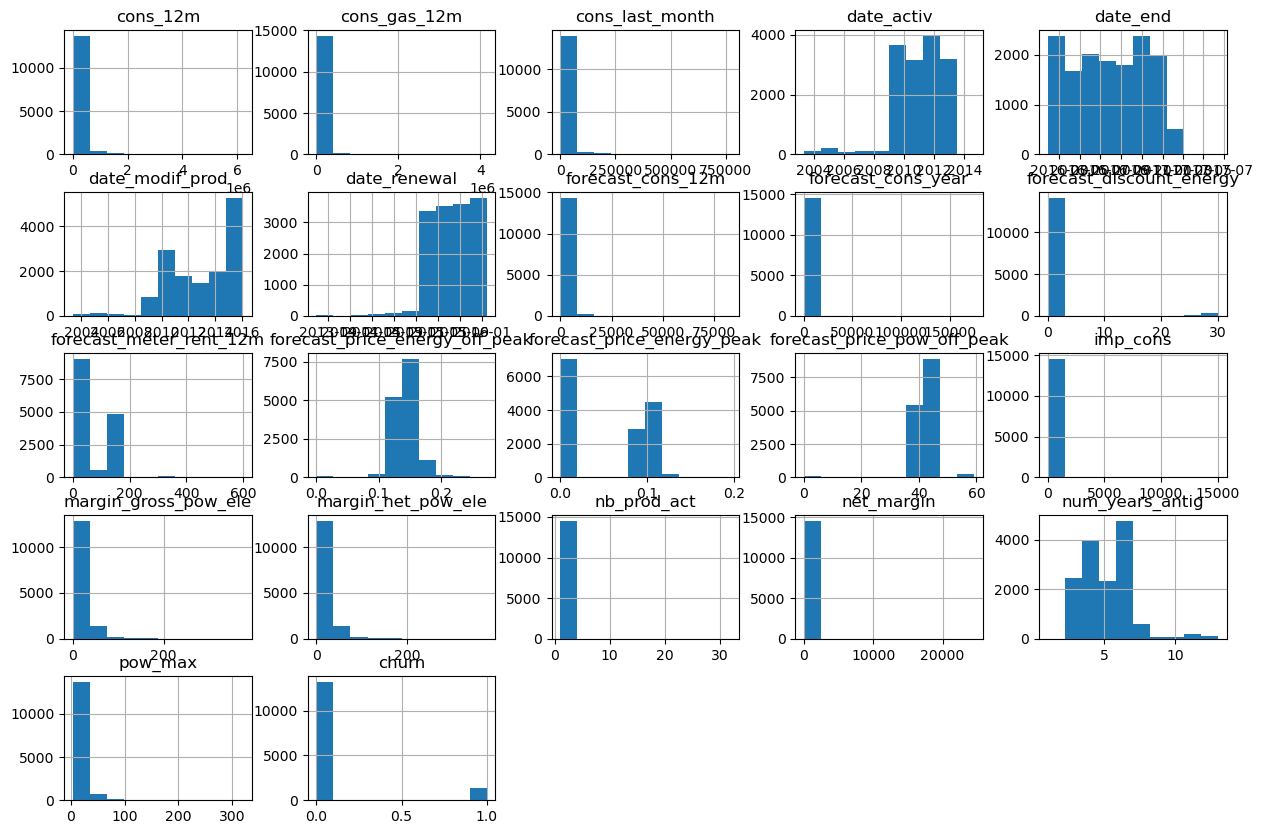

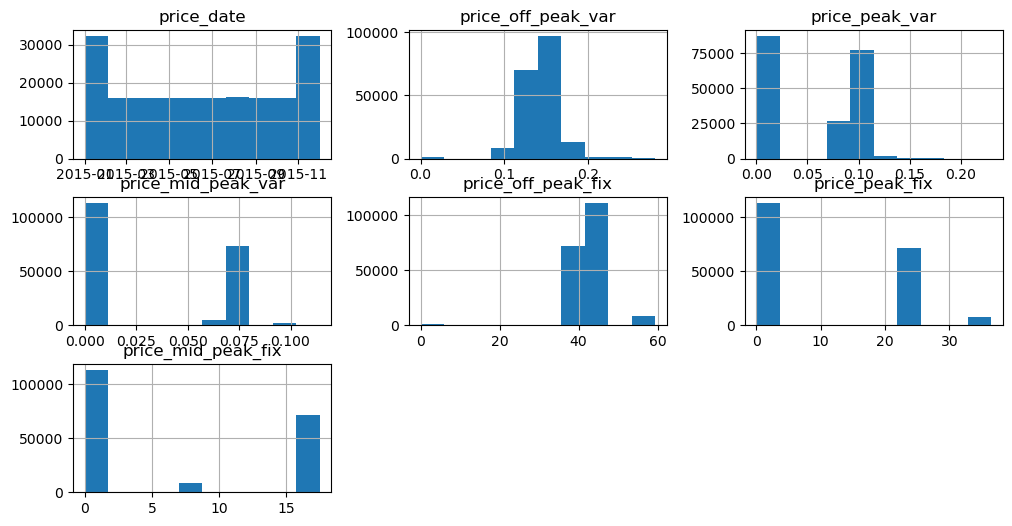

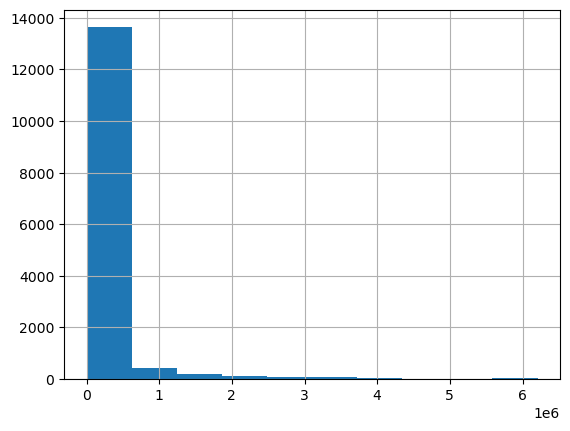

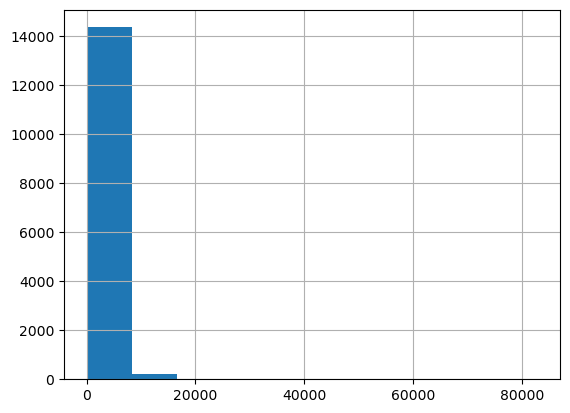

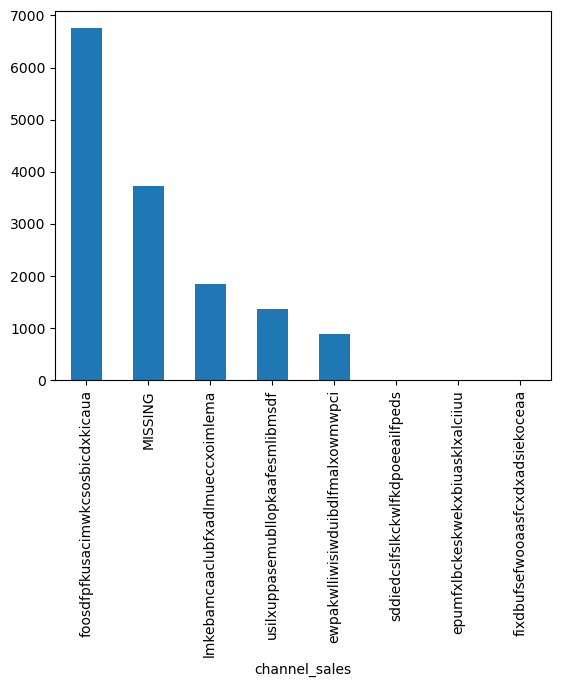

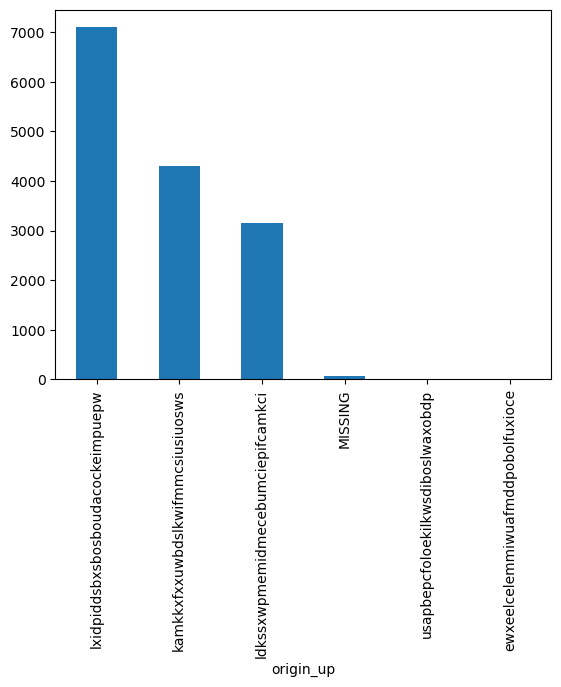

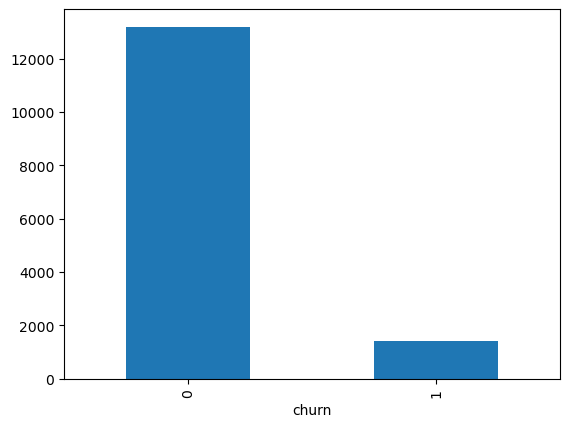

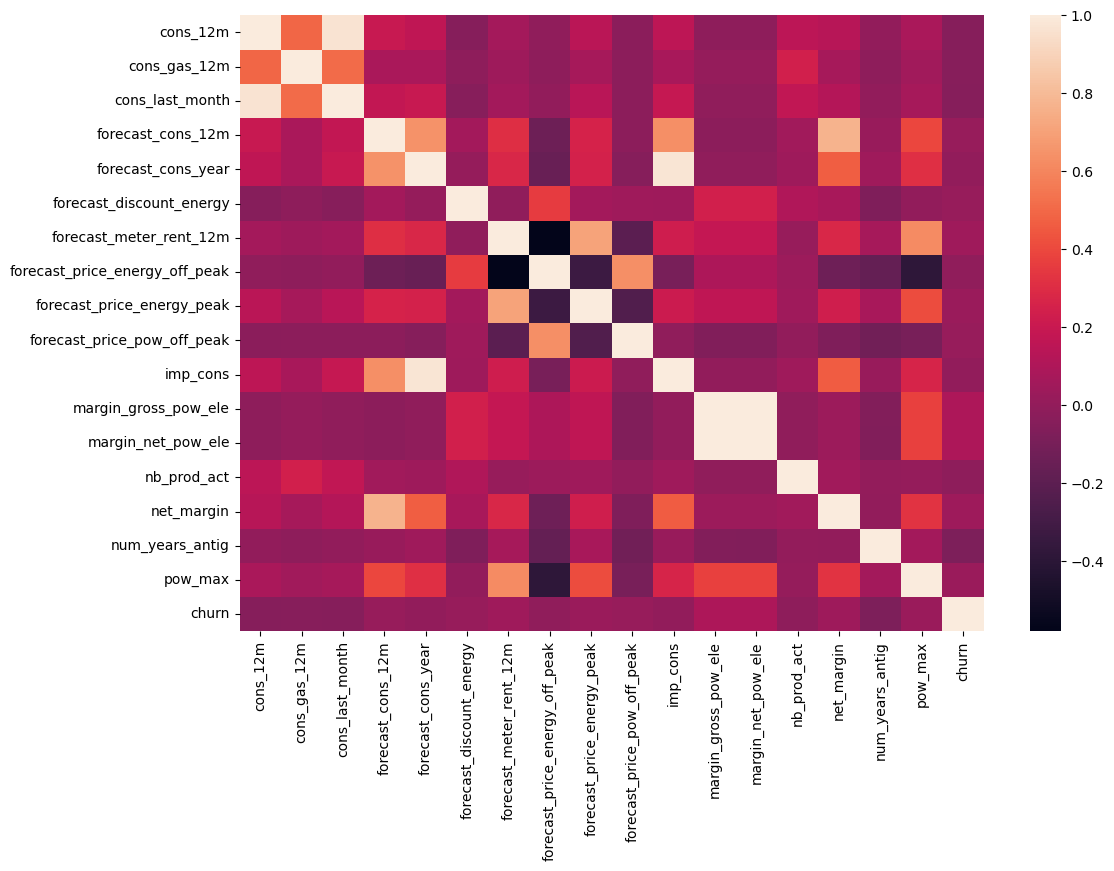

<Figure size 640x480 with 0 Axes>

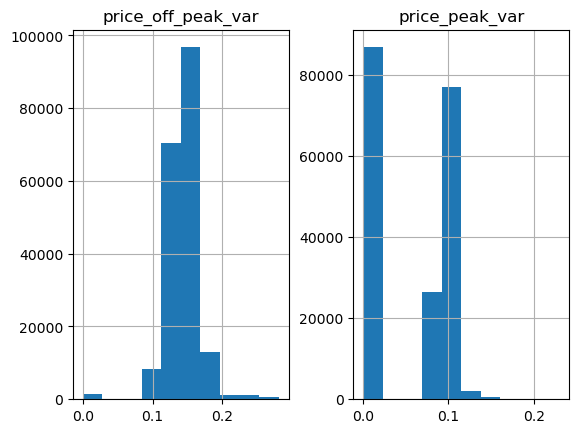

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
client_df = pd.read_csv("client_data (1).csv")
price_df = pd.read_csv("price_data (1).csv")

# Basic info
print(client_df.shape)
print(price_df.shape)

print(client_df.dtypes)
print(price_df.dtypes)

client_df.info()
price_df.info()

# Convert date columns
date_cols = ['date_activ', 'date_end', 'date_modif_prod', 'date_renewal']
for col in date_cols:
    client_df[col] = pd.to_datetime(client_df[col], errors='coerce')

price_df['price_date'] = pd.to_datetime(price_df['price_date'], errors='coerce')

# Missing values
print(client_df.isnull().sum())
print(price_df.isnull().sum())

# Descriptive stats
print(client_df.describe())
print(price_df.describe())

# Histograms
client_df.hist(figsize=(15,10))
plt.show()

price_df.hist(figsize=(12,6))
plt.show()

# Individual distributions
plt.figure()
client_df['cons_12m'].hist()
plt.show()

plt.figure()
client_df['forecast_cons_12m'].hist()
plt.show()

# Categorical columns
plt.figure()
client_df['channel_sales'].value_counts().plot(kind='bar')
plt.show()

plt.figure()
client_df['origin_up'].value_counts().plot(kind='bar')
plt.show()

# Churn
plt.figure()
client_df['churn'].value_counts().plot(kind='bar')
plt.show()

# Correlation
plt.figure(figsize=(12,8))
sns.heatmap(client_df.corr(numeric_only=True))
plt.show()

# Price analysis
plt.figure()
price_df[['price_off_peak_var','price_peak_var']].hist()
plt.show()